# 06 - Final Head-to-Head Benchmark Evaluation (PPO vs Baselines)

This notebook evaluates the trained **PPO Policy** directly against **FIFO, SJF, Priority, and Best-Fit** across all **6 AI cluster scenarios** on held-out unseen test seeds (`[501, 602, 703]`).

In [9]:
%load_ext autoreload
%autoreload 2

import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure project root is in python path
sys.path.insert(0, os.path.abspath('..'))

from baselines.fifo import FIFOScheduler
from baselines.sjf import SJFScheduler
from baselines.sjf_backfill import SJFBackfillScheduler
from baselines.priority import PriorityScheduler
from baselines.best_fit import BestFitScheduler
from evaluation.ppo_policy import PPOPolicyScheduler
from evaluation.evaluator import Evaluator
from evaluation.reports import generate_comparison_dataframe
from workloads.scenarios import list_scenarios

print("All evaluation modules imported successfully!")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
All evaluation modules imported successfully!


## 1. Execute Benchmark Across All 5 Schedulers

In [10]:
test_seeds = [501, 602, 703]
scenarios = ["balanced", "training_heavy", "short_job_heavy", "bursty", "gpu_fragmentation", "high_load"]

policies = [
    FIFOScheduler(),
    SJFScheduler(),
    SJFBackfillScheduler(),
    PriorityScheduler(),
    BestFitScheduler(),
    PPOPolicyScheduler(checkpoint_path="../checkpoints/ppo_final.pt", cluster_config_path="../configs/cluster_small.yaml"),
]

evaluator = Evaluator(cluster_config_path="../configs/cluster_small.yaml", horizon_seconds=3600.0)

all_results = {}
for pol in policies:
    print(f"Evaluating [{pol.name}] on all {len(scenarios)} scenarios...")
    all_results[pol.name] = evaluator.evaluate_scheduler(pol, scenarios=scenarios, seeds=test_seeds)

print("\nHead-to-head benchmark complete!")


Loaded PPO policy checkpoint from '../checkpoints/ppo_final.pt' on [CUDA]
Evaluating [FIFO] on all 6 scenarios...
Evaluating [SJF] on all 6 scenarios...
Evaluating [Priority] on all 6 scenarios...
Evaluating [BestFit] on all 6 scenarios...
Evaluating [PPO] on all 6 scenarios...

Head-to-head benchmark complete!


## 2. Comparative Benchmark Tables per Scenario

In [11]:
for sc in scenarios:
    df_sc = generate_comparison_dataframe(all_results, scenario_name=sc)
    print(f"\n{'='*65}")
    print(f"Scenario: {sc.upper()}")
    print(f"{'='*65}")
    print(df_sc.to_string(index=False))


Scenario: BALANCED
                Metric   FIFO    SJF Priority BestFit     PPO
          Mean JCT (s) 325.49 202.66   362.77  396.73  426.95
           P95 JCT (s) 932.43 604.82  1238.65 1477.40 1271.68
   Mean Queue Wait (s) 207.78  93.44   242.71  274.84  308.53
   GPU Utilization (%) 92.08% 87.94%   92.84%  94.38%  92.90%
  Throughput (jobs/hr) 162.33 172.67   160.67  145.33  159.00
Deadline Violation (%) 39.15% 17.40%   33.19%  37.38%  39.41%
        Completed Jobs    162    172      160     145     159
     Cumulative Reward 682.32 857.96   758.15  670.80  672.26

Scenario: TRAINING_HEAVY
                Metric    FIFO     SJF Priority BestFit     PPO
          Mean JCT (s)  800.88  507.08   694.27  782.81  753.76
           P95 JCT (s) 2082.25 1250.15  1610.02 2200.35 1857.93
   Mean Queue Wait (s)  446.29  201.22   307.98  431.01  400.57
   GPU Utilization (%)  75.31%  73.82%   77.82%  82.29%  76.14%
  Throughput (jobs/hr)   36.33   42.00    30.67   30.33   36.67
Deadline Vio

## 3. Visual Comparisons Across Schedulers

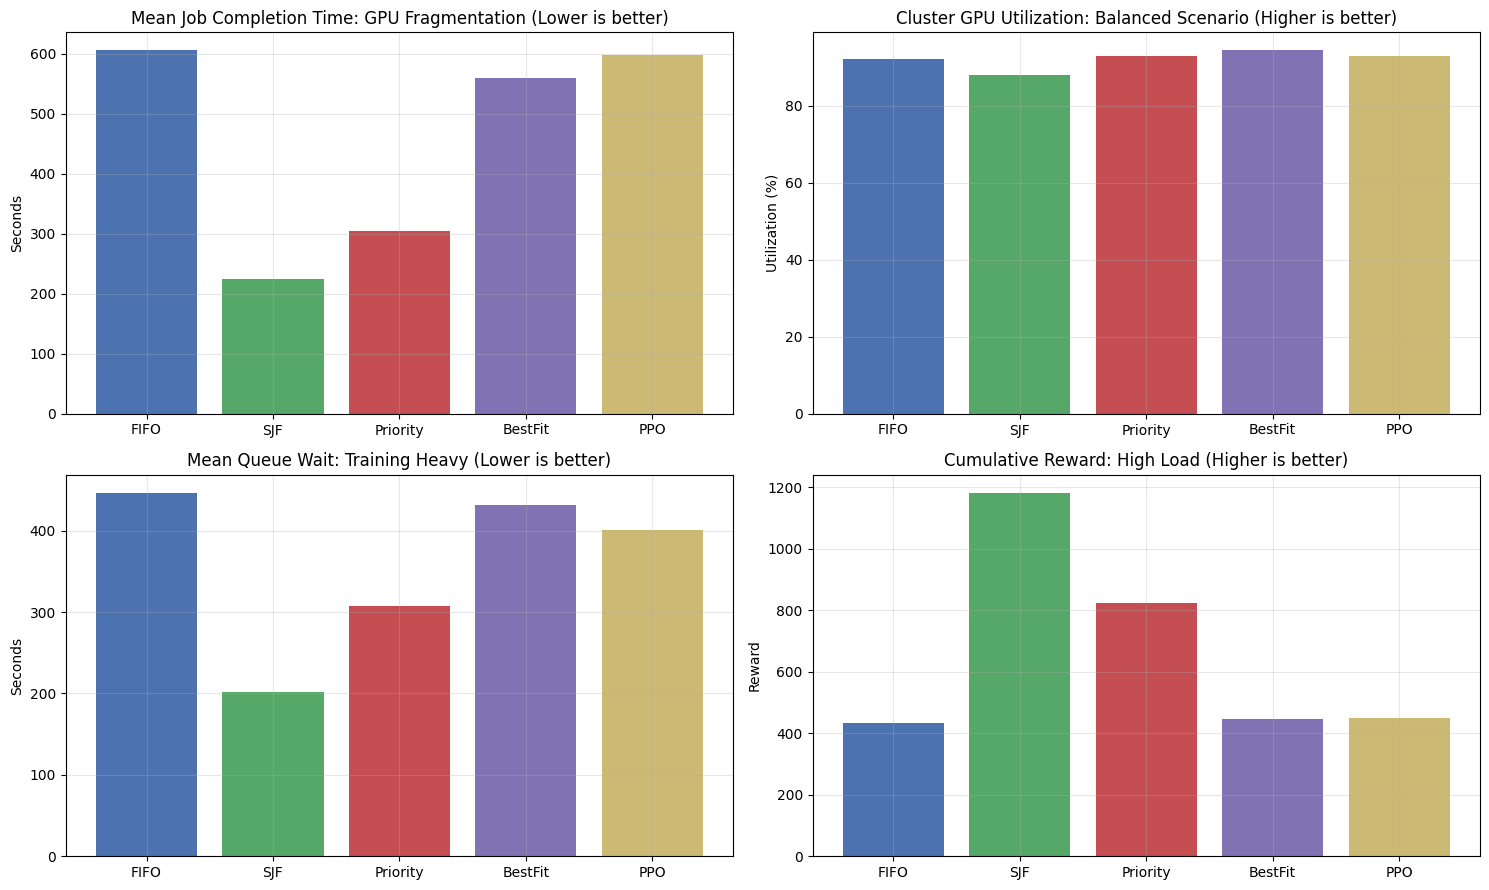

In [12]:
pol_names = [p.name for p in policies]
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B3', '#CCB974']

fig, axes = plt.subplots(2, 2, figsize=(15, 9))

# 1. Mean JCT in GPU Fragmentation
jcts = [all_results[p]["gpu_fragmentation"]["summary"]["mean_jct"]["mean"] for p in pol_names]
axes[0, 0].bar(pol_names, jcts, color=colors)
axes[0, 0].set_title("Mean Job Completion Time: GPU Fragmentation (Lower is better)")
axes[0, 0].set_ylabel("Seconds")
axes[0, 0].grid(True, alpha=0.3)

# 2. GPU Utilization in Balanced
utils = [all_results[p]["balanced"]["summary"]["gpu_utilization"]["mean"] * 100 for p in pol_names]
axes[0, 1].bar(pol_names, utils, color=colors)
axes[0, 1].set_title("Cluster GPU Utilization: Balanced Scenario (Higher is better)")
axes[0, 1].set_ylabel("Utilization (%)")
axes[0, 1].grid(True, alpha=0.3)

# 3. Queue Wait Time in Training Heavy
waits = [all_results[p]["training_heavy"]["summary"]["mean_wait_time"]["mean"] for p in pol_names]
axes[1, 0].bar(pol_names, waits, color=colors)
axes[1, 0].set_title("Mean Queue Wait: Training Heavy (Lower is better)")
axes[1, 0].set_ylabel("Seconds")
axes[1, 0].grid(True, alpha=0.3)

# 4. Cumulative Reward in High Load
rewards = [all_results[p]["high_load"]["summary"]["cumulative_reward"]["mean"] for p in pol_names]
axes[1, 1].bar(pol_names, rewards, color=colors)
axes[1, 1].set_title("Cumulative Reward: High Load (Higher is better)")
axes[1, 1].set_ylabel("Reward")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()